# Stacked Area Chart

A stacked area chart shows how a total splits into parts along an ordered axis, usually time: each series fills a band on top of the one below, so the top edge traces the total and the band thicknesses show how it is made up. This guide shows how to create stacked area charts with the [datachart.charts.StackedAreaChart](../../../references/charts/stackedareachart/#datachart.charts.StackedAreaChart) function, starting with the basics and building up to worked examples on real data.

Looking for a specific customization? Jump straight to the [quick reference](#customizing-the-stacked-area-chart), which maps common tasks to the parameter or style attribute that does the job.

In [1]:
from datachart.charts import StackedAreaChart

## Basics

The examples in this guide share one dataset: the world's electricity generation by source, in terawatt-hours (TWh) per year from 2000 to 2023, for coal, gas, nuclear, hydro, wind, solar, and everything else (oil, bioenergy, geothermal). The values are approximate: rounded and smoothed from the annual figures in Ember's *Global Electricity Review*, so they follow the real trends and end on the 2023 totals, but a single in-between year should not be quoted from them. They live in a hidden cell. `generation` holds one series per source, in the order they stack; `generation_grouped` folds the same numbers into three groups (fossil for coal and gas, low-carbon for nuclear, hydro, wind and solar, and other) for the charts that need fewer bands. Generation is a textbook part-to-whole story: the total nearly doubled while the mix underneath it shifted, coal held its ground, and wind and solar grew from almost nothing to more than a tenth of the whole.

In [2]:
YEARS = list(range(2000, 2024))

# world electricity generation by source (TWh), approximate: rounded and smoothed from Ember
GENERATION = {
    "Coal": [5993, 6070, 6350, 6800, 7100, 7322, 7700, 8200, 8300, 8200, 8673, 9200,
             9300, 9600, 9700, 9538, 9500, 9800, 10100, 9900, 9421, 10200, 10300, 10434],
    "Gas": [2753, 2880, 3000, 3100, 3320, 3681, 3830, 4100, 4260, 4230, 4831, 4900,
            5080, 5050, 5150, 5543, 5800, 5900, 6100, 6300, 6268, 6500, 6600, 6634],
    "Nuclear": [2591, 2637, 2660, 2635, 2740, 2768, 2790, 2720, 2730, 2690, 2756, 2580,
                2460, 2480, 2530, 2571, 2610, 2640, 2700, 2790, 2674, 2800, 2680, 2686],
    "Hydro": [2696, 2620, 2700, 2730, 2880, 2982, 3110, 3150, 3290, 3330, 3532, 3560,
              3740, 3830, 3920, 3890, 4050, 4100, 4200, 4270, 4355, 4300, 4340, 4210],
    "Wind": [31, 38, 52, 63, 85, 104, 133, 171, 220, 276, 342, 437,
             524, 640, 716, 833, 960, 1130, 1270, 1420, 1591, 1850, 2100, 2304],
    "Solar": [1, 1, 2, 2, 3, 4, 6, 8, 12, 20, 32, 63,
              97, 136, 197, 250, 329, 443, 570, 690, 846, 1030, 1300, 1629],
    "Other": [1450, 1470, 1480, 1500, 1520, 1530, 1540, 1560, 1560, 1540, 1580, 1600,
              1620, 1640, 1650, 1660, 1680, 1700, 1720, 1730, 1700, 1720, 1740, 1760],
}
SOURCES = list(GENERATION)
TOTALS = [sum(GENERATION[source][i] for source in SOURCES) for i in range(len(YEARS))]

generation = [
    [{"x": year, "y": twh} for year, twh in zip(YEARS, GENERATION[source])]
    for source in SOURCES
]

# the same generation in three groups
GROUPS = {
    "Fossil": ["Coal", "Gas"],
    "Low-carbon": ["Nuclear", "Hydro", "Wind", "Solar"],
    "Other": ["Other"],
}
generation_grouped = [
    [{"x": year, "y": sum(GENERATION[source][i] for source in members)} for i, year in enumerate(YEARS)]
    for members in GROUPS.values()
]

The data is a list of series, one per source, the first at the bottom of the stack. Each series is a list of points with the year as `x` and the generation as `y`, and every series holds the same years in the same order, because the bands sit on top of one another point by point:

In [3]:
{source: points[:3] for source, points in zip(SOURCES, generation)}

{'Coal': [{'x': 2000, 'y': 5993},
  {'x': 2001, 'y': 6070},
  {'x': 2002, 'y': 6350}],
 'Gas': [{'x': 2000, 'y': 2753},
  {'x': 2001, 'y': 2880},
  {'x': 2002, 'y': 3000}],
 'Nuclear': [{'x': 2000, 'y': 2591},
  {'x': 2001, 'y': 2637},
  {'x': 2002, 'y': 2660}],
 'Hydro': [{'x': 2000, 'y': 2696},
  {'x': 2001, 'y': 2620},
  {'x': 2002, 'y': 2700}],
 'Wind': [{'x': 2000, 'y': 31}, {'x': 2001, 'y': 38}, {'x': 2002, 'y': 52}],
 'Solar': [{'x': 2000, 'y': 1}, {'x': 2001, 'y': 1}, {'x': 2002, 'y': 2}],
 'Other': [{'x': 2000, 'y': 1450},
  {'x': 2001, 'y': 1470},
  {'x': 2002, 'y': 1480}]}

Seven sources outrun the palette: a theme's palette has six colors, and the seventh band would repeat the first, which the chart warns about. Colors carry meaning in a stack, so the guide sets its own palette on the configuration with [config.update_config](../../../references/config/#datachart.config.Config.update_config), once, one color per source in stack order: the fossil sources warm, the low-carbon ones cool, the rest grey. Every chart below draws from it unless it sets its own colors; the [Band style](#band-style) section pins the colors per source, so a chart of a few sources keeps them, and where a few sources are the story, the [Emphasis](#emphasis) section mutes the rest.

In [4]:
from datachart.config import config

# fossil sources warm, low-carbon sources cool, the rest grey
SOURCE_COLORS = {
    "Coal": "#5b4636",
    "Gas": "#e07b39",
    "Nuclear": "#7b5ea7",
    "Hydro": "#2e86ab",
    "Wind": "#7fc8e8",
    "Solar": "#f4c542",
    "Other": "#b8b8b8",
}
config.update_config({"color_general_multiple": list(SOURCE_COLORS.values())})

**Basic example.** Only the `data` argument is required. Each source fills the band between the sources below it and its own value, so the top edge of the stack is the world's total generation, and the axes start where the stack does. A single list of points draws one band on its own. The bands take the palette set above, one color per source in stack order.

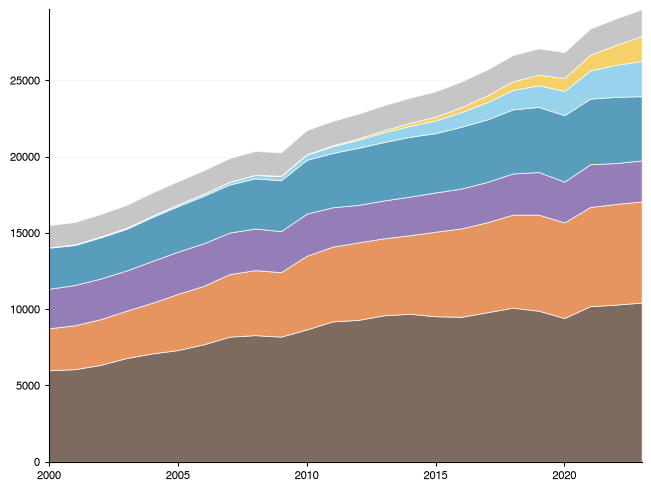

In [5]:
StackedAreaChart(
    # add the data to the chart
    data=generation
).show()

## Customizing the Stacked Area Chart

Every customization is either a keyword argument of `StackedAreaChart` or a `plot_area_*` / `plot_stackedarea_*` attribute of its `style` dictionary. The table maps common tasks to the one you need and links to the subsection that shows it.

| I want to…                                        | Use                                                                 | See |
| :------------------------------------------------ | :------------------------------------------------------------------ | :-- |
| add a title and axis labels                       | `title`, `xlabel`, `ylabel`                                         | [Title, axis labels and ticks](#title-axis-labels-and-ticks) |
| set custom tick positions and labels              | `xticks`, `xticklabels`, `yticks`, `yticklabels`, `xtickrotate`     | [Title, axis labels and ticks](#title-axis-labels-and-ticks) |
| format the tick labels                            | `xticks_format`, `yticks_format`                                    | [Title, axis labels and ticks](#title-axis-labels-and-ticks) |
| fix the axis range                                | `xmin`, `xmax`, `ymin`, `ymax`                                      | [Title, axis labels and ticks](#title-axis-labels-and-ticks) |
| resize the figure                                 | `figsize`                                                           | [Figure size and grid](#figure-size-and-grid) |
| show grid lines                                   | `show_grid`                                                         | [Figure size and grid](#figure-size-and-grid) |
| fix the aspect ratio of the axes                  | `aspect_ratio`                                                      | [Figure size and grid](#figure-size-and-grid) |
| name the series, title and place the legend       | `subtitle`, `show_legend`, `legend`                                 | [Legend](#legend) |
| name each band where it ends                      | `show_labels`, `label_position`                                     | [Legend](#legend) |
| change the band colors, alpha, hatch, or edges    | `style={"plot_area_color": ..., "plot_stackedarea_alpha": ...}`     | [Band style](#band-style) |
| outline the top of every band                     | `style={"plot_stackedarea_outline": True}`                          | [Band style](#band-style) |
| show shares instead of totals                     | `baseline=STACKED_AREA_BASELINE.PERCENT`                            | [Baseline](#baseline) |
| centre the stack or draw a streamgraph            | `baseline=STACKED_AREA_BASELINE.SYM`, `.WIGGLE`, `.WEIGHTED_WIGGLE` | [Baseline](#baseline) |
| print the values on the bands                     | `show_values`, `value_format`, `value_step`                         | [Value labels](#value-labels) |
| highlight some series, mute the rest              | `emphasis`, `emphasis_rule`                                         | [Emphasis](#emphasis) |
| mark a year or a level                            | `vlines`, `hlines`, `dlines`                                       | [Reference lines](#reference-lines) |
| keep reference lines visible over the bands       | `style={"plot_area_zorder": 1}`                                     | [Reference lines](#reference-lines) |
| shade a period or a range of levels               | `vspans`, `hspans`                                                  | [Reference bands](#reference-bands) |
| put a note on the chart                           | `texts`                                                             | [Text annotations](#text-annotations) |
| draw each series unstacked in its own subplot     | `subplots`, `sharex`, `sharey`, `max_cols`                          | [Subplots](#subplots) |
| draw a line over the stack, or arrange several    | `Panel`, `Grid`                                                     | [Composing stacked areas](#composing-stacked-areas) |
| plot against real dates                           | `datetime` objects as `x`, `xticks_format`                          | [Datetime axis](#datetime-axis) |
| plot data with other key names                    | `x`, `y`                                                            | [Custom data keys](#custom-data-keys) |
| restyle every chart at once                       | `config.set_theme`                                                  | [Themes](#themes) |
| save the chart to a file                          | `save_figure`                                                       | [Saving Figures](../../utility/saving/) guide |

The parameters that accept a constant, with the class in [datachart.constants](../../../references/constants/) that lists its values:

| Parameter | Constant |
| :-- | :-- |
| `baseline` | [`STACKED_AREA_BASELINE`](../../../references/constants/#datachart.constants.STACKED_AREA_BASELINE) |
| `label_position` | [`LINE_LABEL_POSITION`](../../../references/constants/#datachart.constants.LINE_LABEL_POSITION) |
| `xticks_format` | [`VALUE_FORMAT`](../../../references/constants/#datachart.constants.VALUE_FORMAT), [`DATE_FORMAT`](../../../references/constants/#datachart.constants.DATE_FORMAT) |
| `emphasis` | [`EMPHASIS`](../../../references/constants/#datachart.constants.EMPHASIS) |
| `figsize` | [`FIG_SIZE`](../../../references/constants/#datachart.constants.FIG_SIZE) |
| `legend={"location": ..., "alignment": ...}` | [`LEGEND_LOCATION`](../../../references/constants/#datachart.constants.LEGEND_LOCATION), [`LEGEND_ALIGN`](../../../references/constants/#datachart.constants.LEGEND_ALIGN) |
| `show_grid` | [`SHOW_GRID`](../../../references/constants/#datachart.constants.SHOW_GRID) |
| `value_format` | [`VALUE_FORMAT`](../../../references/constants/#datachart.constants.VALUE_FORMAT) |
| `aspect_ratio` | [`ASPECT_RATIO`](../../../references/constants/#datachart.constants.ASPECT_RATIO) |
| `scalex` | [`AXIS_SCALE`](../../../references/constants/#datachart.constants.AXIS_SCALE) |
| `scaley` | [`AXIS_SCALE`](../../../references/constants/#datachart.constants.AXIS_SCALE) |
| `yticks_format` | [`VALUE_FORMAT`](../../../references/constants/#datachart.constants.VALUE_FORMAT), [`DATE_FORMAT`](../../../references/constants/#datachart.constants.DATE_FORMAT) |

The full list of style attributes is in the [datachart.typings.StackedAreaStyleAttrs](../../../references/charts/stackedareachart/#datachart.typings.StackedAreaStyleAttrs) and [datachart.typings.AreaStyleAttrs](../../../references/typings/#datachart.typings.AreaStyleAttrs) types; the full list of parameters is in the [datachart.charts.StackedAreaChart](../../../references/charts/stackedareachart/#datachart.charts.StackedAreaChart) reference.

### Title, axis labels and ticks

A stack without a title and axis labels is a pile of colors; `title`, `xlabel` and `ylabel` say what is stacked and in what unit. The ticks are the reader's ruler: `xticks` and `yticks` set their positions (`xticklabels` and `yticklabels` replace the labels), `xticks_format` and `yticks_format` format them (a [VALUE_FORMAT](../../../references/constants/#datachart.constants.VALUE_FORMAT) member or a `"{x:.1f}"` style string on a value axis), and `xtickrotate` and `ytickrotate` tilt them. `xmin`, `xmax`, `ymin` and `ymax` fix the axis range; a stack rests on zero, so the value axis already starts there, and `ymax` is mostly used to leave headroom for a legend or a note. The `scalex` and `scaley` parameters take a [AXIS_SCALE](../../../references/constants/#datachart.constants.AXIS_SCALE) member as on every chart, but a logarithmic value axis cannot show the zero a stack rests on and distorts the band thicknesses, so leave them linear. Here the years tick every five years and end on the last year of the data, and the thousands print with a separator.

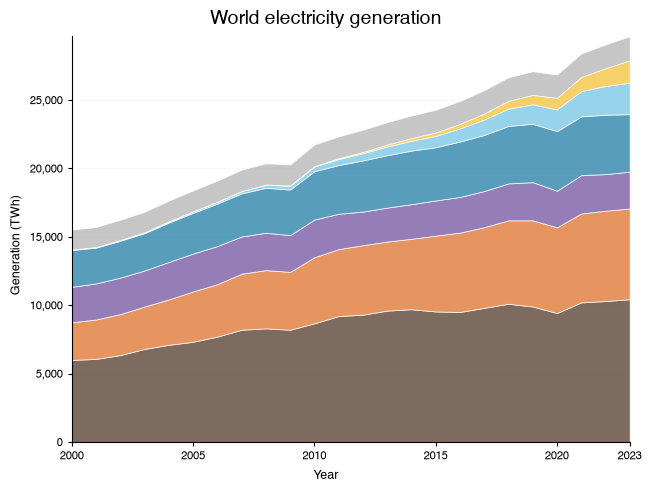

In [6]:
StackedAreaChart(
    data=generation,
    # add the title
    title="World electricity generation",
    # add the x and y axis labels
    xlabel="Year",
    ylabel="Generation (TWh)",
    # a tick every five years, ending on the last year; thousands with a separator
    xticks=[2000, 2005, 2010, 2015, 2020, 2023],
    yticks_format="{x:,.0f}",
).show()

### Figure size and grid

Twenty-four years of seven bands read best wide, with enough height for the thin bands to stay visible. `figsize` takes a `(width, height)` tuple in inches or one of the presets in [datachart.constants.FIG_SIZE](../../../references/constants/#datachart.constants.FIG_SIZE), sized for a full or half page width. Grid lines let the eye carry the top of the stack across to the value axis; `show_grid` draws them with a [SHOW_GRID](../../../references/constants/#datachart.constants.SHOW_GRID) member, `Y` for the value axis alone, `X` for the time axis, `BOTH` for both. `aspect_ratio` fixes the ratio of the axes rather than of the figure ([ASPECT_RATIO](../../../references/constants/#datachart.constants.ASPECT_RATIO)); a stacked area chart never needs it, so the examples leave it at the default.

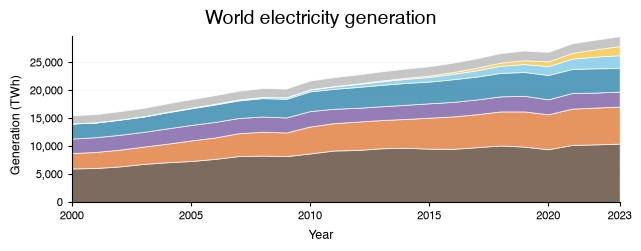

In [7]:
from datachart.constants import FIG_SIZE, SHOW_GRID

StackedAreaChart(
    data=generation,
    title="World electricity generation",
    xlabel="Year",
    ylabel="Generation (TWh)",
    xticks=[2000, 2005, 2010, 2015, 2020, 2023],
    yticks_format="{x:,.0f}",
    # a wide, short figure
    figsize=FIG_SIZE.FULL_SHORT,
    # grid lines along the value axis only
    show_grid=SHOW_GRID.Y,
).show()

### Legend

Seven bands are seven colors, and only a legend says which is which. `subtitle` names the series, one name per series in the order of `data`, and `show_legend` lists them; the legend follows the input order, so the bottom of the stack comes first. `legend` says where and how, with a `title`, a `location` from [LEGEND_LOCATION](../../../references/constants/#datachart.constants.LEGEND_LOCATION), the number of columns `ncols`, and the `alignment` of the entries from [LEGEND_ALIGN](../../../references/constants/#datachart.constants.LEGEND_ALIGN); a field left out falls back to the theme ([LegendSettingAttrs](../../../references/typings/#datachart.typings.LegendSettingAttrs)). A rising stack leaves its empty corner at the top left, and a little headroom from `ymax` makes room for a two-column legend there.

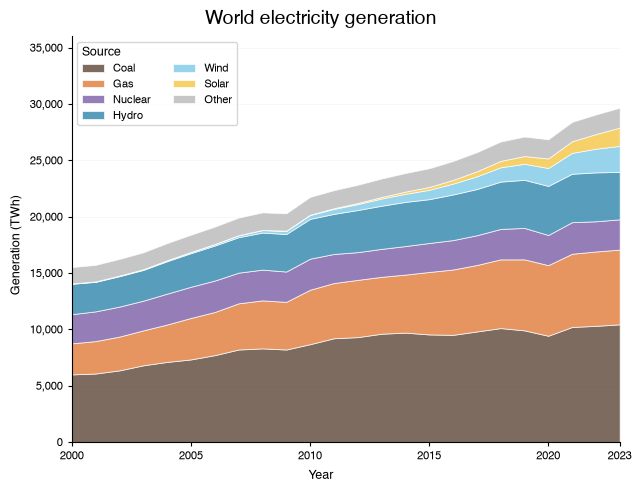

In [8]:
from datachart.constants import LEGEND_LOCATION

StackedAreaChart(
    data=generation,
    # name the series, bottom of the stack first
    subtitle=SOURCES,
    show_legend=True,
    # a titled, two-column legend in the empty corner
    legend={"title": "Source", "location": LEGEND_LOCATION.UPPER_LEFT, "ncols": 2},
    title="World electricity generation",
    xlabel="Year",
    ylabel="Generation (TWh)",
    xticks=[2000, 2005, 2010, 2015, 2020, 2023],
    yticks_format="{x:,.0f}",
    figsize=FIG_SIZE.FULL_MEDIUM,
    show_grid=SHOW_GRID.Y,
    # headroom for the legend
    ymax=36000,
).show()

End labels name each band where it ends instead. `show_labels` prints each series' name at the midpoint of its band at the last `x`, in the text color, and `label_position` picks the end with a [LINE_LABEL_POSITION](../../../references/constants/#datachart.constants.LINE_LABEL_POSITION) member: `END` (the default), `START`, or `BOTH`. Seven names at one edge spread apart along the value axis, so a thin band still gets its name beside the stack, and the legend can go.

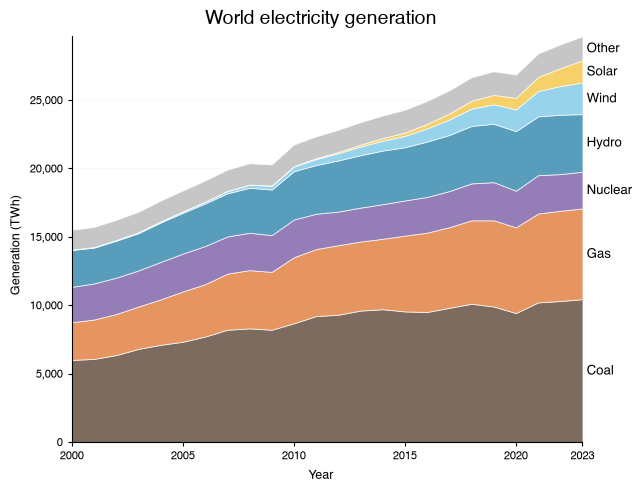

In [9]:
StackedAreaChart(
    data=generation,
    subtitle=SOURCES,
    # each source named where its band ends
    show_labels=True,
    title="World electricity generation",
    xlabel="Year",
    ylabel="Generation (TWh)",
    xticks=[2000, 2005, 2010, 2015, 2020, 2023],
    yticks_format="{x:,.0f}",
    figsize=FIG_SIZE.FULL_MEDIUM,
    show_grid=SHOW_GRID.Y,
).show()

### Band style

Colors carry meaning in a stack: sources that belong together should look alike, and a reader should not have to consult the legend for every band. The `style` dictionary sets the look of the bands: the fill color and hatch come from the `plot_area_*` attributes ([AreaStyleAttrs](../../../references/typings/#datachart.typings.AreaStyleAttrs)), and `plot_stackedarea_alpha`, the stroke between the bands (`plot_stackedarea_edge_color`, `plot_stackedarea_edge_width`) and `plot_stackedarea_outline`, which draws the top edge of every band as a line in the `plot_line_*` style, are the stack's own ([StackedAreaStyleAttrs](../../../references/charts/stackedareachart/#datachart.typings.StackedAreaStyleAttrs)). A single dictionary applies to every series; a list aligned with `data` styles each on its own, and any attribute left out keeps the value of the active theme. `SOURCE_STYLE` pins each source's color from `SOURCE_COLORS`, so a chart of a few sources keeps them (the [examples](#real-world-examples) at the end draw three), and adds a hatch from [HATCH_STYLE](../../../references/constants/#datachart.constants.HATCH_STYLE) marking the miscellaneous band. It also sets `plot_area_zorder`, the drawing order of the bands: by default the bands are drawn over reference lines and over lines composed with them, and a lower value sends them underneath (the [Reference lines](#reference-lines) section shows why that matters). The rest of the guide reuses `SOURCE_STYLE`.

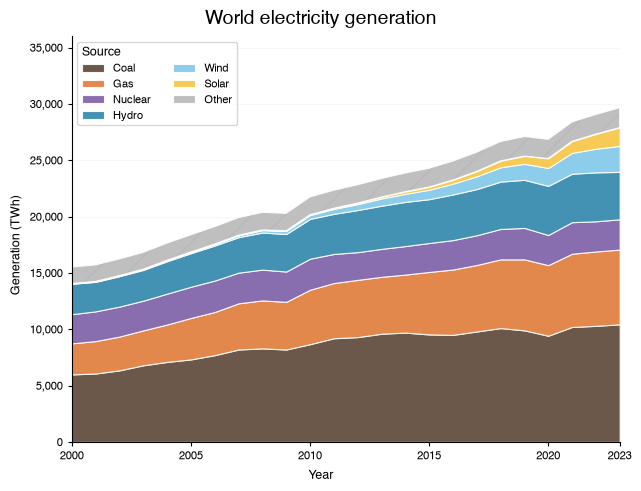

In [10]:
from datachart.constants import HATCH_STYLE

SOURCE_STYLE = [
    {
        "plot_area_color": SOURCE_COLORS[source],
        "plot_area_hatch": HATCH_STYLE.DIAGONAL if source == "Other" else None,
        "plot_stackedarea_alpha": 0.9,
        # a thin white stroke between the bands
        "plot_stackedarea_edge_color": "white",
        "plot_stackedarea_edge_width": 0.8,
        # draw the bands under reference lines and composed lines
        "plot_area_zorder": 1,
    }
    for source in SOURCES
]

StackedAreaChart(
    data=generation,
    # one style per series
    style=SOURCE_STYLE,
    subtitle=SOURCES,
    show_legend=True,
    legend={"title": "Source", "location": LEGEND_LOCATION.UPPER_LEFT, "ncols": 2},
    title="World electricity generation",
    xlabel="Year",
    ylabel="Generation (TWh)",
    xticks=[2000, 2005, 2010, 2015, 2020, 2023],
    yticks_format="{x:,.0f}",
    figsize=FIG_SIZE.FULL_MEDIUM,
    show_grid=SHOW_GRID.Y,
    ymax=36000,
).show()

### Baseline

The same stack answers different questions depending on where its first band starts, and `baseline` picks that with a [STACKED_AREA_BASELINE](../../../references/constants/#datachart.constants.STACKED_AREA_BASELINE) member. The default, `ZERO`, rests the stack on zero, so the top edge is the total: the chart for *how much is generated, and by what*. `PERCENT` scales every year to 100, so each band is a share of that year's total and the total itself disappears: the chart for *how has the mix changed*. The two charts tell different stories on the same numbers: in terawatt-hours coal has never been higher, in shares it has been slipping since the early 2010s, because everything else grew faster.

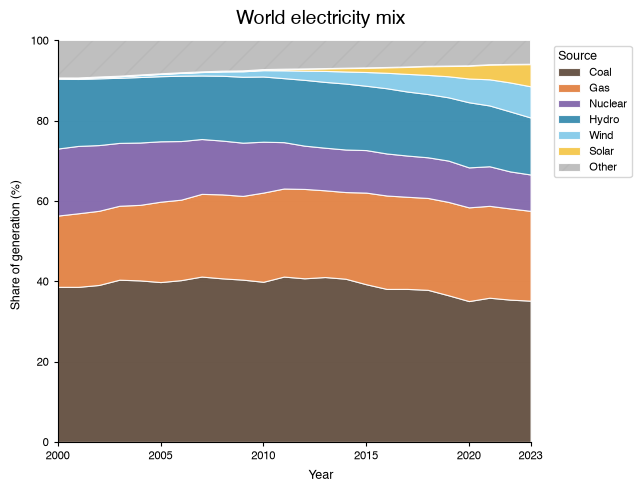

In [11]:
from datachart.constants import STACKED_AREA_BASELINE

StackedAreaChart(
    data=generation,
    # every year sums to 100: the bands are shares
    baseline=STACKED_AREA_BASELINE.PERCENT,
    style=SOURCE_STYLE,
    subtitle=SOURCES,
    show_legend=True,
    legend={"title": "Source", "location": LEGEND_LOCATION.OUTSIDE_RIGHT},
    title="World electricity mix",
    xlabel="Year",
    ylabel="Share of generation (%)",
    xticks=[2000, 2005, 2010, 2015, 2020, 2023],
    figsize=FIG_SIZE.FULL_MEDIUM,
    show_grid=SHOW_GRID.Y,
).show()

Sometimes neither the total nor the shares are the question, only how each part rises and falls: a chart of many series over time, where the reader follows the shape of every band. The remaining baselines float the stack for that, and give up the value axis in exchange. `SYM` centres the stack on zero, so it grows symmetrically up and down, which still shows the total as the overall width but no single band against the axis. `WIGGLE` moves the baseline at every year so that the bands, taken together, slope as little as possible: the streamgraph. `WEIGHTED_WIGGLE` does the same but weighs each band by its size, so the large bands stay the flattest and the eye reads their changes as thickness, not as slope. On all three only the thickness of a band carries its value, so the value axis means nothing and `yticks=[]` hides it. Use them when the series are many and the shapes matter more than any number. The three views below draw the same seven sources: `SYM` and `WIGGLE` tilt the large coal band downward as the stack grows, while `WEIGHTED_WIGGLE` keeps the large bands the flattest, so the growth shows as thickness.

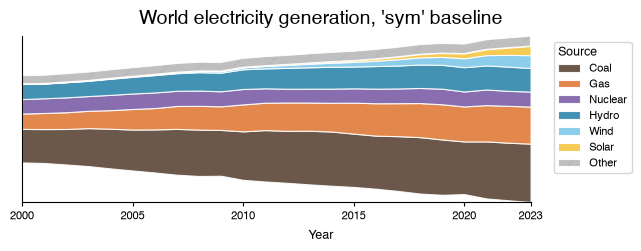

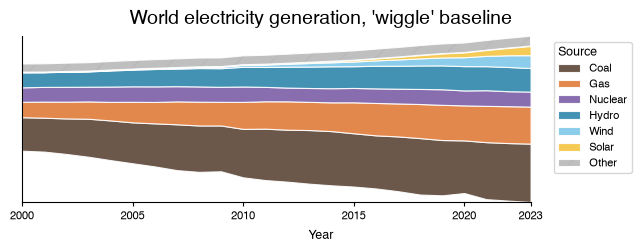

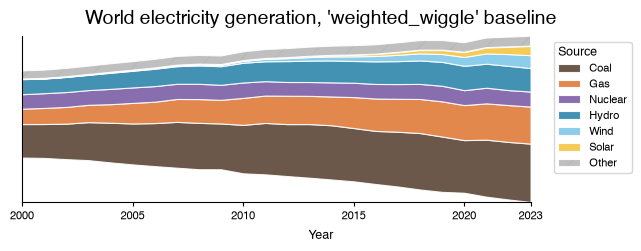

In [12]:
for baseline in [
    STACKED_AREA_BASELINE.SYM,
    STACKED_AREA_BASELINE.WIGGLE,
    STACKED_AREA_BASELINE.WEIGHTED_WIGGLE,
]:
    StackedAreaChart(
        data=generation,
        # a floating stack: only the band thickness carries the value
        baseline=baseline,
        style=SOURCE_STYLE,
        subtitle=SOURCES,
        show_legend=True,
        legend={"title": "Source", "location": LEGEND_LOCATION.OUTSIDE_RIGHT},
        title=f"World electricity generation, '{baseline}' baseline",
        xlabel="Year",
        xticks=[2000, 2005, 2010, 2015, 2020, 2023],
        # the value axis has no meaning on a floating stack
        yticks=[],
        figsize=FIG_SIZE.FULL_SHORT,
    ).show()

### Value labels

When the shares themselves are the message, `show_values` prints each series' value at the midpoint of its band, `value_format` formats it (a [VALUE_FORMAT](../../../references/constants/#datachart.constants.VALUE_FORMAT) constant or any `"{x:.1f}"`, `"{:.1f}%"` or `"%g"` style string), and `value_step` labels every Nth year, because twenty-four labels per band would overlap (by default the step is the smallest that keeps neighbouring labels apart). The label font size, color and padding are the `plot_value_*` style attributes ([ValueLabelStyleAttrs](../../../references/typings/#datachart.typings.ValueLabelStyleAttrs)). Seven bands are too many to label legibly, so the example uses the three groups on the percent baseline, labeled every fourth year; the first label sits on the left edge, and `xmin` moves the edge out a little to leave it whole. The share of coal and gas reads off directly: 56% in 2000, up to 63% in 2012, and back to 58% in 2020.

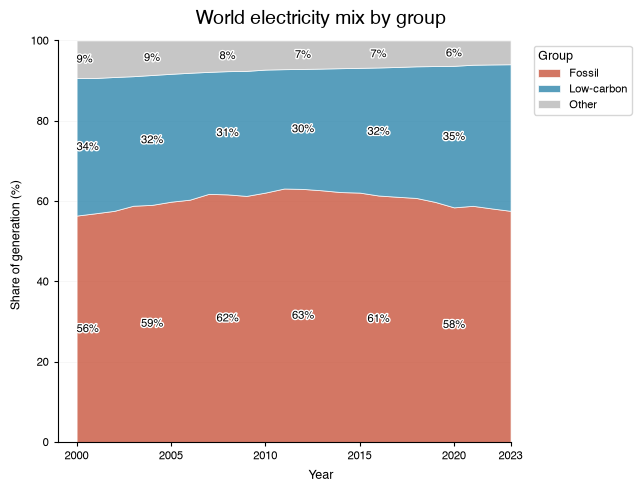

In [13]:
StackedAreaChart(
    data=generation_grouped,
    baseline=STACKED_AREA_BASELINE.PERCENT,
    style=[{"plot_area_color": color} for color in ("#c8553d", "#2e86ab", "#b8b8b8")],
    subtitle=list(GROUPS),
    show_legend=True,
    legend={"title": "Group", "location": LEGEND_LOCATION.OUTSIDE_RIGHT},
    # print the share of every group every fourth year
    show_values=True,
    value_format="{:.0f}%",
    value_step=4,
    title="World electricity mix by group",
    xlabel="Year",
    ylabel="Share of generation (%)",
    xticks=[2000, 2005, 2010, 2015, 2020, 2023],
    # room for the labels on the left edge
    xmin=1999,
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Emphasis

A stack of seven bands makes no single point; emphasis picks one. `emphasis` takes one role per series, aligned with `data` like `subtitle` and `style`: `"highlight"` brings a band to the front, `"background"` mutes it (the theme's muted color at a lower alpha, dropped from the legend), and `None` leaves it as it is. The stack itself does not change: a muted band keeps its place and thickness, so the highlighted bands stay exactly where the data puts them. The roles are also available as the [EMPHASIS](../../../references/constants/#datachart.constants.EMPHASIS) constants, and the [Highlighting](../../styling/highlighting/) guide covers emphasis across every chart type and theme. Highlighting wind and solar on the percent baseline turns the rest of the mix into context, and shows the two of them growing from a sliver to more than a tenth of the whole.

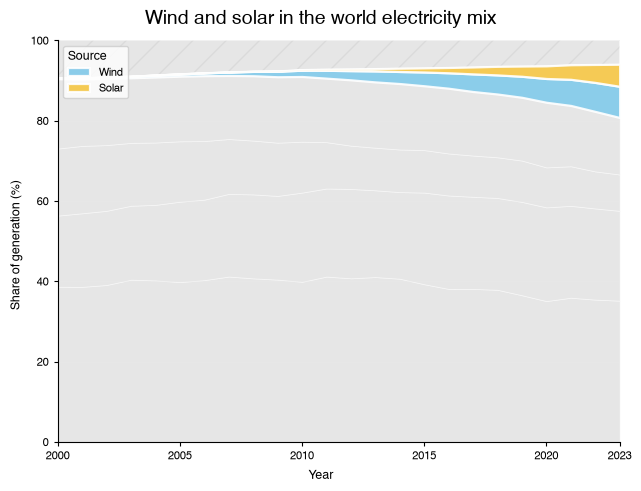

In [14]:
from datachart.constants import EMPHASIS

StackedAreaChart(
    data=generation,
    baseline=STACKED_AREA_BASELINE.PERCENT,
    style=SOURCE_STYLE,
    # wind and solar are the question, the rest the context
    emphasis=[
        EMPHASIS.HIGHLIGHT if source in ("Wind", "Solar") else EMPHASIS.BACKGROUND
        for source in SOURCES
    ],
    subtitle=SOURCES,
    show_legend=True,
    legend={"title": "Source", "location": LEGEND_LOCATION.UPPER_LEFT},
    title="Wind and solar in the world electricity mix",
    xlabel="Year",
    ylabel="Share of generation (%)",
    xticks=[2000, 2005, 2010, 2015, 2020, 2023],
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

`emphasis_rule` picks the series from the data instead of naming them. It is a one-key dictionary: `{"top": n}` or `{"bottom": n}` by rank, `{"above": v}` or `{"below": v}` (strict), or `{"between": (lo, hi)}` (inclusive), read against a summary of each series' own `y` values (never its stacked position): the mean by default, or the `"median"`, `"min"`, `"max"` or `"sum"` named by a `"by"` key. The series that match are highlighted, the rest muted, and an explicit `emphasis` role wins over the rule. The two smallest sources on average over the period are wind and solar, so `{"bottom": 2}` finds them without naming them; the [Highlighting](../../styling/highlighting/#emphasis-picked-by-a-rule) guide covers the rule on every chart.

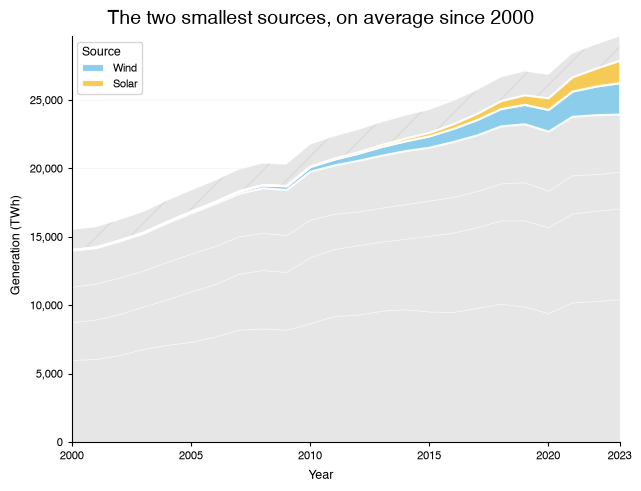

In [15]:
StackedAreaChart(
    data=generation,
    style=SOURCE_STYLE,
    # the two series with the smallest mean generation
    emphasis_rule={"bottom": 2},
    subtitle=SOURCES,
    show_legend=True,
    legend={"title": "Source", "location": LEGEND_LOCATION.UPPER_LEFT},
    title="The two smallest sources, on average since 2000",
    xlabel="Year",
    ylabel="Generation (TWh)",
    xticks=[2000, 2005, 2010, 2015, 2020, 2023],
    yticks_format="{x:,.0f}",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Reference lines

A reference line puts a year or a level on the chart: an event on the time axis, a benchmark on the value axis. `vlines` draws a vertical line at an `x` value and `hlines` a horizontal one at a `y` value; each takes a dictionary or a list of them, with the position, an optional `label` for the legend and a `style` with the `plot_vline_*` or `plot_hline_*` attributes ([VLineSettingAttrs](../../../references/typings/#datachart.typings.VLineSettingAttrs), [HLineSettingAttrs](../../../references/typings/#datachart.typings.HLineSettingAttrs)); [LINE_STYLE](../../../references/constants/#datachart.constants.LINE_STYLE) holds the dash patterns. Two things need care on a stack. A line given for the whole chart is drawn by each series, so a stack of seven would draw and list every line seven times; attach the lines to one series instead, with a list aligned with `data` that holds the lines in the first slot and `None` in the rest. And the bands are drawn over the lines by default, which hides a line wherever it crosses the stack; the `"plot_area_zorder": 1` in `SOURCE_STYLE` draws the bands underneath. The example marks the Paris Agreement and the pandemic year, and the level of total generation in 2000: every band above that line is growth the world has added since.

`dlines` completes the trio. Where `vlines` fixes an x and `hlines` a y, a diagonal is fixed by a `slope` and an `intercept`, so it runs through the data space instead of across it; `dlines={}` on its own draws the parity line `y = x`. It spans the axes unless `xmin` and `xmax` clip it to a segment, and takes the same optional `label` and `style`; the keys are listed in [DLineSettingAttrs](../../../references/typings/#datachart.typings.DLineSettingAttrs). Both axes carry numbers here, so a diagonal is a growth path: the straight line from the first year's total to the last. Where the top of the stack runs above it, generation grew faster than the even path; where it dips below, slower.

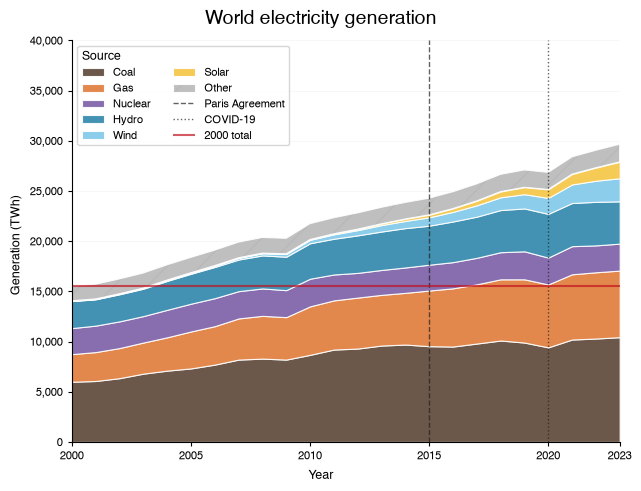

In [16]:
from datachart.constants import LINE_STYLE

StackedAreaChart(
    data=generation,
    style=SOURCE_STYLE,
    subtitle=SOURCES,
    show_legend=True,
    legend={"title": "Source", "location": LEGEND_LOCATION.UPPER_LEFT, "ncols": 2},
    # two events on the time axis, attached to the first series so they draw once
    vlines=[
        [
            {"x": 2015, "label": "Paris Agreement", "style": {"plot_vline_color": "#1f1f1f", "plot_vline_style": LINE_STYLE.DASHED}},
            {"x": 2020, "label": "COVID-19", "style": {"plot_vline_color": "#1f1f1f", "plot_vline_style": LINE_STYLE.DOTTED}},
        ]
    ]
    + [None] * (len(SOURCES) - 1),
    # the total generation of 2000, on the value axis
    hlines=[{"y": TOTALS[0], "label": "2000 total", "style": {"plot_hline_color": "#c1121f", "plot_hline_width": 1.5}}]
    + [None] * (len(SOURCES) - 1),
    title="World electricity generation",
    xlabel="Year",
    ylabel="Generation (TWh)",
    xticks=[2000, 2005, 2010, 2015, 2020, 2023],
    yticks_format="{x:,.0f}",
    figsize=FIG_SIZE.FULL_MEDIUM,
    ymax=40000,
).show()

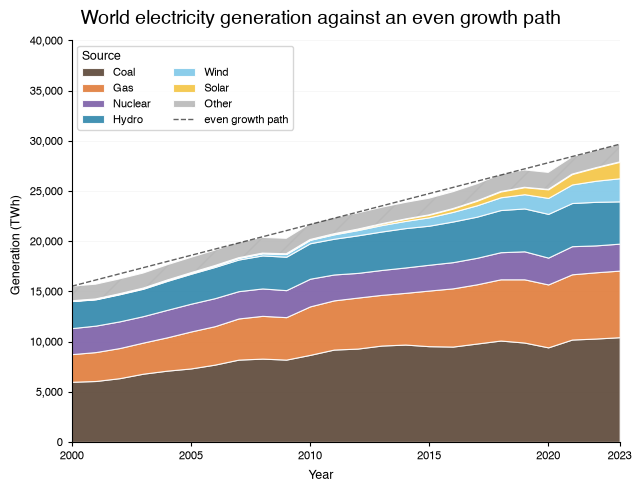

In [17]:
years = [point["x"] for point in generation[0]]
# the straight path from the first year's total to the last
per_year = (TOTALS[-1] - TOTALS[0]) / (years[-1] - years[0])

StackedAreaChart(
    data=generation,
    style=SOURCE_STYLE,
    subtitle=SOURCES,
    # the even growth path across the whole period
    dlines={
        "slope": per_year,
        "intercept": TOTALS[0] - per_year * years[0],
        "label": "even growth path",
        "style": {"plot_dline_color": "#1f1f1f", "plot_dline_style": LINE_STYLE.DASHED},
    },
    title="World electricity generation against an even growth path",
    xlabel="Year",
    ylabel="Generation (TWh)",
    xticks=[2000, 2005, 2010, 2015, 2020, 2023],
    yticks_format="{x:,.0f}",
    figsize=FIG_SIZE.FULL_MEDIUM,
    show_legend=True,
    legend={"title": "Source", "location": LEGEND_LOCATION.UPPER_LEFT, "ncols": 2},
    ymax=40000,
).show()

### Reference bands

Where a line marks an instant, a band shades a period, or a range of levels. `vspans` shades between two `x` values and `hspans` between two `y` values; each is a dictionary or a list of them with the bounds (`xmin` / `xmax` or `ymin` / `ymax`, an omitted bound runs to the axis edge), an optional `label` for the legend and a `style` with the `plot_vspan_*` or `plot_hspan_*` attributes ([VSpanSettingAttrs](../../../references/typings/#datachart.typings.VSpanSettingAttrs), [HSpanSettingAttrs](../../../references/typings/#datachart.typings.HSpanSettingAttrs)). A band given for the whole chart is shaded once, so no per-series list is needed. The example shades the two years of the financial crisis, the one period before 2020 in which the world's generation stopped growing, and the stack shows where the dip came from: coal, gas and nuclear all fell in 2009, while hydro and wind kept growing.

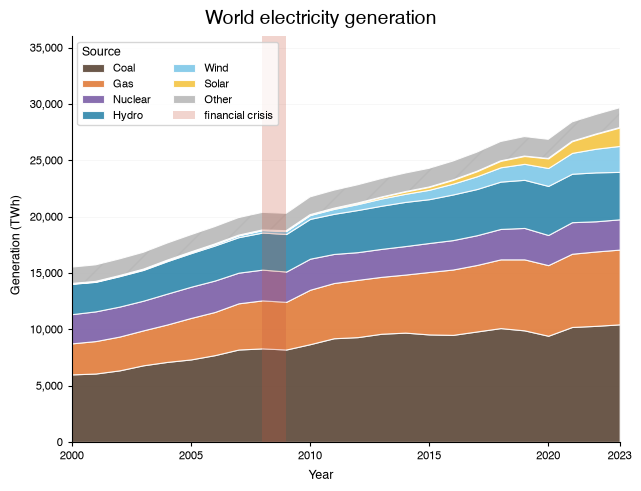

In [18]:
StackedAreaChart(
    data=generation,
    style=SOURCE_STYLE,
    subtitle=SOURCES,
    show_legend=True,
    legend={"title": "Source", "location": LEGEND_LOCATION.UPPER_LEFT, "ncols": 2},
    # shade the financial crisis; one band applies to the whole stack
    vspans={"xmin": 2008, "xmax": 2009, "label": "financial crisis", "style": {"plot_vspan_color": "#c8553d"}},
    title="World electricity generation",
    xlabel="Year",
    ylabel="Generation (TWh)",
    xticks=[2000, 2005, 2010, 2015, 2020, 2023],
    yticks_format="{x:,.0f}",
    figsize=FIG_SIZE.FULL_MEDIUM,
    ymax=36000,
).show()

### Text annotations

A note says what a shape means. `texts` places text on the chart, with an optional `target` to draw a connector to a point; the position is in data coordinates by default (year, value) or in axes fractions with `"coords": "axes"`, which keeps the note in place whatever the axis limits. In a stack the point to target is the top of a band, which is the sum of that series and every series below it, so the example computes it. Like a reference line, a note given for the whole chart is drawn once per series, so it goes in the first slot of a per-series list. The [Text Annotations](../../utility/annotations/) guide covers placement, connector looks and styling. The note below points at the year solar generation passed 1,000 TWh.

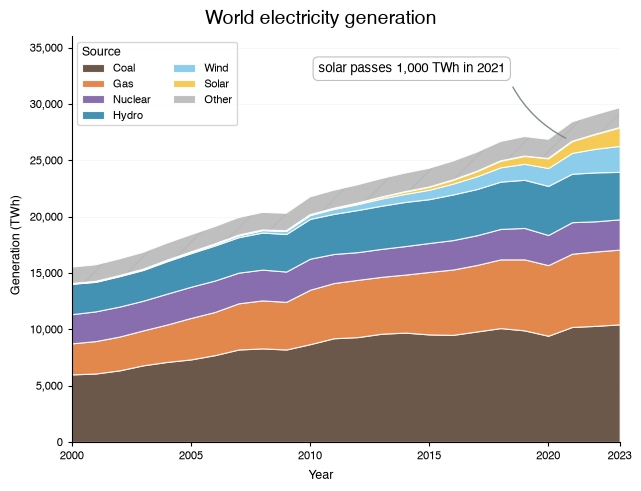

In [19]:
SOLAR_1000 = next(year for year, twh in zip(YEARS, GENERATION["Solar"]) if twh >= 1000)
# the top of the solar band that year: solar plus everything stacked below it
solar_top = sum(GENERATION[source][YEARS.index(SOLAR_1000)] for source in SOURCES[: SOURCES.index("Solar") + 1])

StackedAreaChart(
    data=generation,
    style=SOURCE_STYLE,
    subtitle=SOURCES,
    show_legend=True,
    legend={"title": "Source", "location": LEGEND_LOCATION.UPPER_LEFT, "ncols": 2},
    # a note pinned to the axes, pointing at the top of the solar band; drawn once
    texts=[
        {
            "text": f"solar passes 1,000 TWh in {SOLAR_1000}",
            "x": 0.45,
            "y": 0.92,
            "coords": "axes",
            "target": (SOLAR_1000, solar_top),
        }
    ]
    + [None] * (len(SOURCES) - 1),
    title="World electricity generation",
    xlabel="Year",
    ylabel="Generation (TWh)",
    xticks=[2000, 2005, 2010, 2015, 2020, 2023],
    yticks_format="{x:,.0f}",
    figsize=FIG_SIZE.FULL_MEDIUM,
    ymax=36000,
).show()

## Multiple Stacked Area Charts

A stacked area chart is already a multi-series chart: the list-of-lists `data`, the aligned `subtitle`, `style` and `emphasis` lists, and the legend are covered above. This section takes the stack apart into subplots, and puts stacked area figures together with other figures.

### Subplots

Stacking makes the total easy to read and the individual sources hard: only the bottom band has a flat base, and every other band's shape is bent by the bands below it. `subplots=True` draws each series unstacked in its own panel, from zero, so the shape of every source can be read on its own. `subtitle` titles the panels; `title`, `xlabel` and `ylabel` stay global; `max_cols` limits the panels per row. `sharex=True` keeps one time axis for all of them and `sharey=True` one value axis, so a band in one panel is comparable with a band in the next; the shared value axis is fixed with `ymax`, a little above coal's peak. Seen this way, nuclear's flat line and the two hockey sticks of wind and solar are plain, and coal's rise is not the only story.

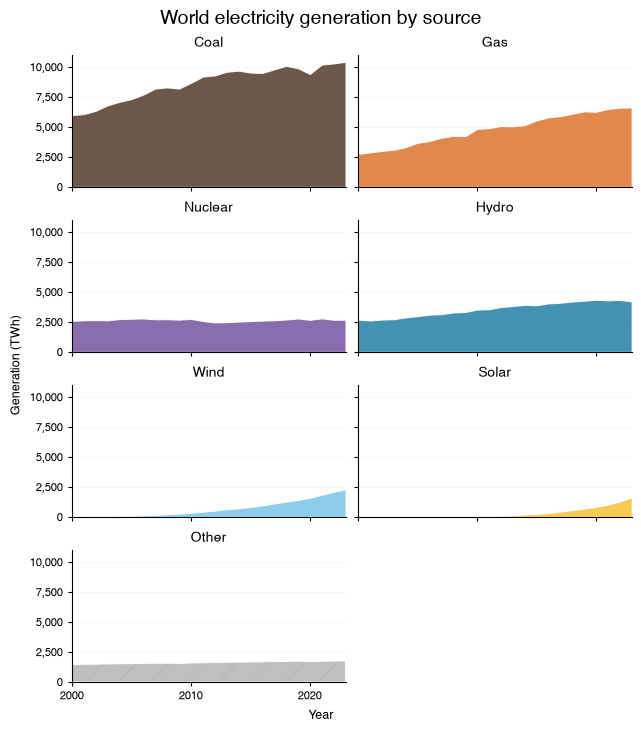

In [20]:
StackedAreaChart(
    data=generation,
    style=SOURCE_STYLE,
    subtitle=SOURCES,
    # one panel per source, unstacked, two per row
    subplots=True,
    max_cols=2,
    # one time axis and one value axis for all panels
    sharex=True,
    sharey=True,
    ymax=11000,
    title="World electricity generation by source",
    xlabel="Year",
    ylabel="Generation (TWh)",
    xticks=[2000, 2010, 2020],
    yticks_format="{x:,.0f}",
    figsize=FIG_SIZE.FULL_TALL,
).show()

### Composing stacked areas

A stacked area figure composes like any other. [Panel](../../utility/panel/) draws several figures on one set of axes: a line chart drawn over the stack sits on top of it without joining it, which is the natural way to put a related total or a target against the stack. The line below is the low-carbon total (nuclear, hydro, wind and solar together) over the full mix, and it answers a question the stack cannot: how the four low-carbon sources together compare with coal, the bottom band. The line meets the top of the coal band around 2020, so the low-carbon sources now generate about as much as coal does. `Panel` takes the figures, the shared labels, and its own `show_legend`; the bands of `SOURCE_STYLE` sit underneath, so the line stays visible across them (a figure's `"z_order"` in `Panel` sets the order explicitly).

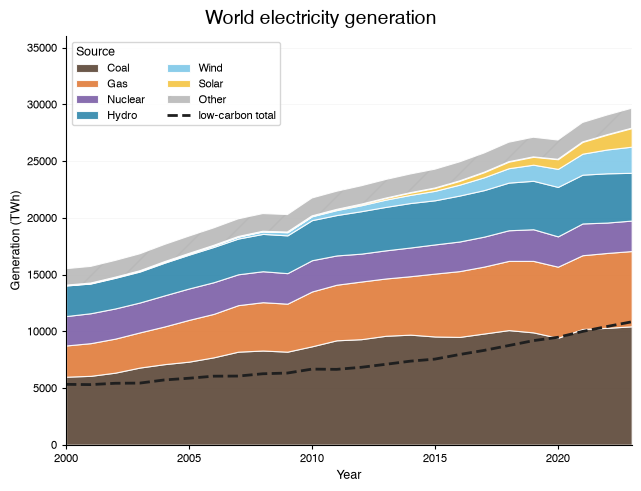

In [21]:
from datachart.charts import LineChart
from datachart.utils import Panel

low_carbon = [
    {"x": year, "y": sum(GENERATION[source][i] for source in GROUPS["Low-carbon"])}
    for i, year in enumerate(YEARS)
]

stack = StackedAreaChart(data=generation, style=SOURCE_STYLE, subtitle=SOURCES)
total = LineChart(
    data=low_carbon,
    subtitle="low-carbon total",
    style={"plot_line_color": "#1f1f1f", "plot_line_style": LINE_STYLE.DASHED, "plot_line_width": 2},
)
Panel(
    [stack, total],
    title="World electricity generation",
    xlabel="Year",
    ylabel_left="Generation (TWh)",
    figsize=FIG_SIZE.FULL_MEDIUM,
    show_legend=True,
    legend={"title": "Source", "location": LEGEND_LOCATION.UPPER_LEFT, "ncols": 2},
    ymax=36000,
).show()

[Grid](../../utility/grid/) arranges stacked area figures next to other figures, each in its own cell, with nested lists as rows. The generation in terawatt-hours spans the top row, and the mix in percent sits next to a bar chart of the 2023 generation by source below it; each figure keeps its own title and baseline, and the grid supplies the shared `xlabel`.

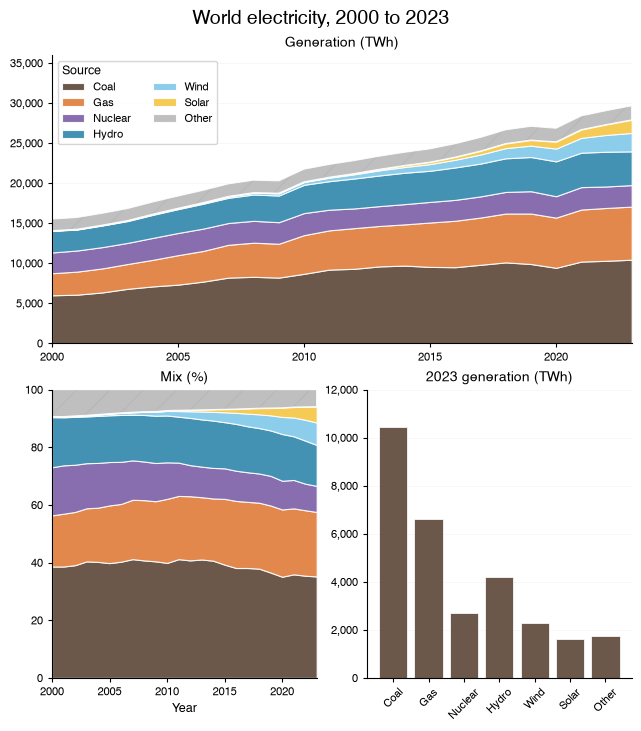

In [22]:
from datachart.charts import BarChart
from datachart.utils import Grid

top = StackedAreaChart(
    data=generation,
    style=SOURCE_STYLE,
    subtitle=SOURCES,
    title="Generation (TWh)",
    show_legend=True,
    legend={"title": "Source", "location": LEGEND_LOCATION.UPPER_LEFT, "ncols": 2},
    yticks_format="{x:,.0f}",
    ymax=36000,
)
left = StackedAreaChart(
    data=generation,
    baseline=STACKED_AREA_BASELINE.PERCENT,
    style=SOURCE_STYLE,
    subtitle=SOURCES,
    title="Mix (%)",
    xlabel="Year",
)
right = BarChart(
    data=[{"label": source, "y": GENERATION[source][-1]} for source in SOURCES],
    style={"plot_bar_color": "#5b4636"},
    title="2023 generation (TWh)",
    xtickrotate=45,
    yticks_format="{x:,.0f}",
)
Grid([[top], [left, right]], title="World electricity, 2000 to 2023", figsize=FIG_SIZE.FULL_TALL).show()

## Additional Features

### Datetime axis

Yearly data sits fine on a numeric axis, but monthly or daily data wants a real time axis, where points land at their elapsed time and the ticks label themselves sensibly. An `x` value that is a real temporal object (a `datetime`, a `date`, a `numpy.datetime64` or a pandas `Timestamp`) does exactly that; date strings such as `"2015-01-01"` are **not** parsed and draw as unordered categories. On a time axis everything that takes an x position takes a date: `xticks`, `xmin` and `xmax`, reference lines and bands, and annotation targets, and `xticks_format` labels the ticks with a [DATE_FORMAT](../../../references/constants/#datachart.constants.DATE_FORMAT) member or any `strftime` pattern. `generation_dated` keys the same generation by the first day of each year; the example starts the axis at 2010, ticks it every five years, and marks the day the Paris Agreement was adopted.

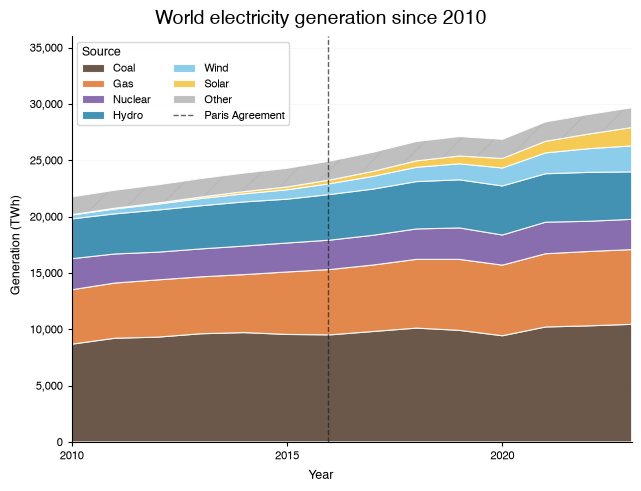

In [23]:
from datetime import date

from datachart.constants import DATE_FORMAT

generation_dated = [
    [{"x": date(year, 1, 1), "y": twh} for year, twh in zip(YEARS, GENERATION[source])]
    for source in SOURCES
]

StackedAreaChart(
    data=generation_dated,
    style=SOURCE_STYLE,
    subtitle=SOURCES,
    show_legend=True,
    legend={"title": "Source", "location": LEGEND_LOCATION.UPPER_LEFT, "ncols": 2},
    # the axis reads as time: a datetime limit, one tick per five years, a dated event
    xmin=date(2010, 1, 1),
    xticks=[date(year, 1, 1) for year in range(2010, 2024, 5)],
    xticks_format=DATE_FORMAT.YEAR,
    vlines=[
        {"x": date(2015, 12, 12), "label": "Paris Agreement", "style": {"plot_vline_color": "#1f1f1f", "plot_vline_style": LINE_STYLE.DASHED}}
    ]
    + [None] * (len(SOURCES) - 1),
    title="World electricity generation since 2010",
    xlabel="Year",
    ylabel="Generation (TWh)",
    yticks_format="{x:,.0f}",
    figsize=FIG_SIZE.FULL_MEDIUM,
    ymax=36000,
).show()

### Custom data keys

Data that comes from a file or an API rarely uses the `x` and `y` keys, and renaming every record just to plot it is a chore. Instead, tell `StackedAreaChart` which keys to read with the `x` and `y` arguments. `generation_records` stores the same generation the way a CSV export would, one record per year and source with a `year` and a `twh` key:

In [24]:
generation_records = [
    [{"year": year, "twh": twh} for year, twh in zip(YEARS, GENERATION[source])]
    for source in SOURCES
]
generation_records[0][:2]

[{'year': 2000, 'twh': 5993}, {'year': 2001, 'twh': 6070}]

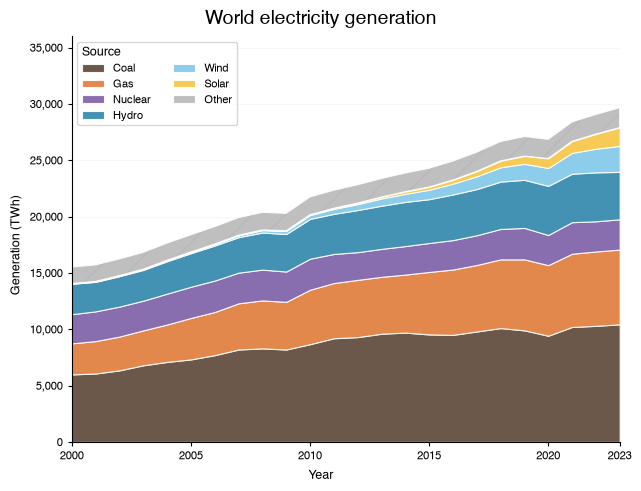

In [25]:
StackedAreaChart(
    data=generation_records,
    # the keys that hold the x and y values
    x="year",
    y="twh",
    style=SOURCE_STYLE,
    subtitle=SOURCES,
    show_legend=True,
    legend={"title": "Source", "location": LEGEND_LOCATION.UPPER_LEFT, "ncols": 2},
    title="World electricity generation",
    xlabel="Year",
    ylabel="Generation (TWh)",
    xticks=[2000, 2005, 2010, 2015, 2020, 2023],
    yticks_format="{x:,.0f}",
    figsize=FIG_SIZE.FULL_MEDIUM,
    ymax=36000,
).show()

### Themes

A theme sets the palette, the band alpha, the stroke between the bands and the furniture of every chart at once, so a report keeps one look without restyling each figure; the [Theme Gallery](../../styling/theme-gallery/) shows the whole suite under each. Apply one with [config.set_theme](../../../references/config/#datachart.config.Config.set_theme) from the [THEME](../../../references/constants/#datachart.constants.THEME) constants, and reset the configuration afterwards so the following charts draw in the default again. The style is resolved when the chart is created, so the figure keeps the theme when it is shown after the reset. A theme brings its own palette, five colors for `INK`, fewer than the seven sources; the example keeps wind and solar in the theme's colors and mutes the rest with `emphasis`, as the [Emphasis](#emphasis) section showed.

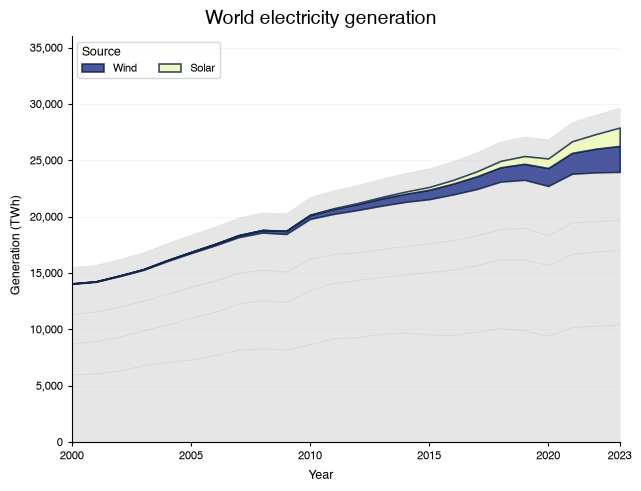

In [26]:
from datachart.constants import THEME

config.set_theme(THEME.INK)
figure = StackedAreaChart(
    data=generation,
    subtitle=SOURCES,
    # the theme's palette has five colors: keep wind and solar
    emphasis=[
        EMPHASIS.HIGHLIGHT if source in ("Wind", "Solar") else EMPHASIS.BACKGROUND
        for source in SOURCES
    ],
    show_legend=True,
    legend={"title": "Source", "location": LEGEND_LOCATION.UPPER_LEFT, "ncols": 2},
    title="World electricity generation",
    xlabel="Year",
    ylabel="Generation (TWh)",
    xticks=[2000, 2005, 2010, 2015, 2020, 2023],
    yticks_format="{x:,.0f}",
    figsize=FIG_SIZE.FULL_MEDIUM,
    ymax=36000,
)
config.reset_config()
figure.show()

## Real-World Examples

The examples below put the features above to work on the generation data, each one answering a question. Any derived data lives in a hidden cell; each example says what its data is and how it is derived.

### Example 1: Has the Fossil Share of Electricity Moved? (Grouped Series, Percent Baseline, Emphasis, and a Note)

Two decades of climate policy, and how much of the world's electricity still comes from burning coal and gas? `generation_grouped` folds the seven sources into fossil (coal, gas), low-carbon (nuclear, hydro, wind, solar) and other, and the percent baseline turns the groups into shares, because the question is about the share, not the amount. The fossil band is highlighted and the other two muted, a dashed line marks the halfway point (drawn over the bands with `plot_area_zorder`), and a note gives the shares at both ends and at the peak. The chart makes one point: coal and gas never fell below half, and after rising to 63% in the early 2010s the share of coal and gas is back near where it was in 2000, because total generation grew almost as fast as the low-carbon sources did. (Oil sits in the other group, so the fossil band here is coal and gas only.)

In [27]:
FOSSIL_SHARE = [100 * point["y"] / total for point, total in zip(generation_grouped[0], TOTALS)]
FOSSIL_2023 = FOSSIL_SHARE[-1]
PEAK_YEAR = YEARS[FOSSIL_SHARE.index(max(FOSSIL_SHARE))]
GROUP_STYLE = [
    {"plot_area_color": color, "plot_area_zorder": 1} for color in ("#c8553d", "#2e86ab", "#b8b8b8")
]

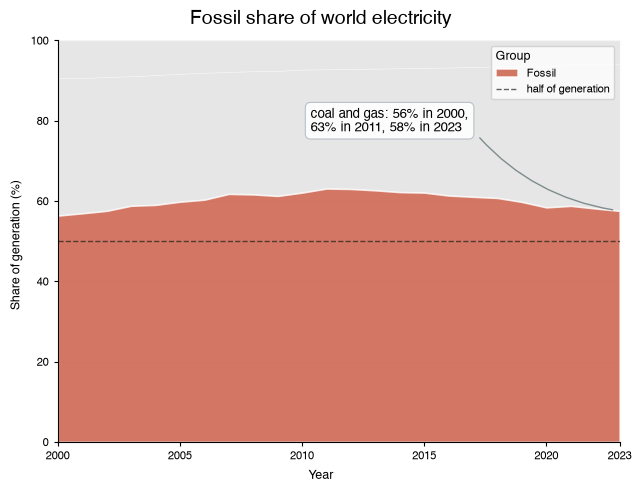

In [28]:
StackedAreaChart(
    data=generation_grouped,
    # shares, not amounts
    baseline=STACKED_AREA_BASELINE.PERCENT,
    style=GROUP_STYLE,
    subtitle=list(GROUPS),
    # fossil is the question, the rest the context
    emphasis=[EMPHASIS.HIGHLIGHT, EMPHASIS.BACKGROUND, EMPHASIS.BACKGROUND],
    show_legend=True,
    legend={"title": "Group", "location": LEGEND_LOCATION.UPPER_RIGHT},
    # the halfway mark, attached to the first series so it draws once
    hlines=[
        {"y": 50, "label": "half of generation", "style": {"plot_hline_color": "#1f1f1f", "plot_hline_style": LINE_STYLE.DASHED}},
        None,
        None,
    ],
    # the shares at both ends and the peak, pointing at the top of the fossil band in 2023
    texts=[
        {
            "text": f"coal and gas: {FOSSIL_SHARE[0]:.0f}% in 2000,\n{max(FOSSIL_SHARE):.0f}% in {PEAK_YEAR}, {FOSSIL_2023:.0f}% in 2023",
            "x": 0.45,
            "y": 0.8,
            "coords": "axes",
            "target": (2023, FOSSIL_2023),
        },
        None,
        None,
    ],
    title="Fossil share of world electricity",
    xlabel="Year",
    ylabel="Share of generation (%)",
    xticks=[2000, 2005, 2010, 2015, 2020, 2023],
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Example 2: Total, Mix, or Shape? Three Baselines on One Dataset (Zero, Percent and Wiggle Baselines, Outlines, and a Grid)

The baseline is a choice about the question, and the same data answers three of them. On the zero baseline the top edge is the total: the world generates nearly twice the electricity it did in 2000. On the percent baseline the total is gone and only the mix remains: coal's share has slipped since the early 2010s and wind and solar took most of what it lost. On the wiggle baseline neither total nor share can be read, only the shape of each band, and a streamgraph of the three renewable sources (hydro, wind and solar) shows steady hydro against the late surge of wind and solar, the bands outlined so that the thin early years stay visible. [Grid](../../utility/grid/) puts the three views in one figure: the total across the top row, the mix and the streamgraph side by side below it.

In [29]:
RENEWABLES = ["Hydro", "Wind", "Solar"]
renewables = [generation[SOURCES.index(source)] for source in RENEWABLES]
RENEWABLES_STYLE = [SOURCE_STYLE[SOURCES.index(source)] for source in RENEWABLES]

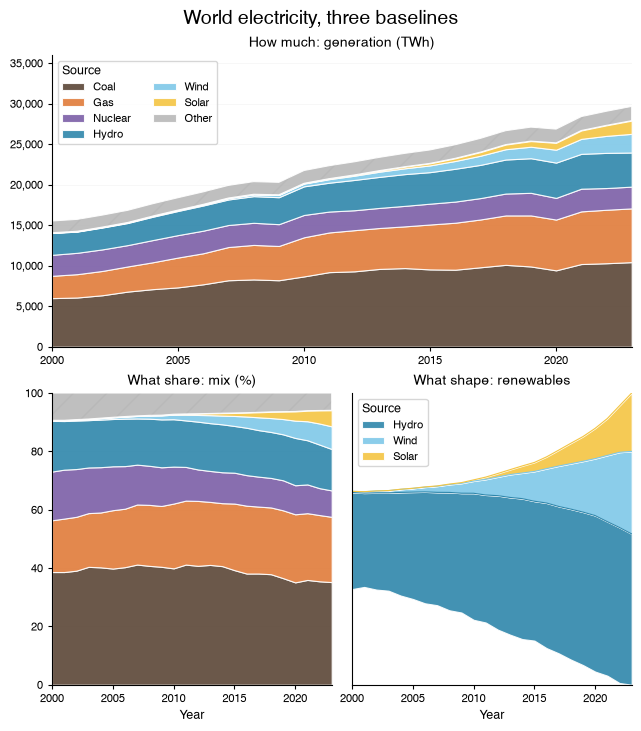

In [30]:
total = StackedAreaChart(
    data=generation,
    style=SOURCE_STYLE,
    subtitle=SOURCES,
    title="How much: generation (TWh)",
    show_legend=True,
    legend={"title": "Source", "location": LEGEND_LOCATION.UPPER_LEFT, "ncols": 2},
    yticks_format="{x:,.0f}",
    ymax=36000,
)
mix = StackedAreaChart(
    data=generation,
    baseline=STACKED_AREA_BASELINE.PERCENT,
    style=SOURCE_STYLE,
    subtitle=SOURCES,
    title="What share: mix (%)",
    xlabel="Year",
)
shape = StackedAreaChart(
    data=renewables,
    baseline=STACKED_AREA_BASELINE.WIGGLE,
    # outlined bands keep the thin early years visible
    style=[{**band, "plot_stackedarea_outline": True, "plot_line_width": 0.8} for band in RENEWABLES_STYLE],
    subtitle=RENEWABLES,
    title="What shape: renewables",
    xlabel="Year",
    show_legend=True,
    legend={"title": "Source", "location": LEGEND_LOCATION.UPPER_LEFT},
    yticks=[],
)
Grid([[total], [mix, shape]], title="World electricity, three baselines", figsize=FIG_SIZE.FULL_TALL).show()

### Example 3: Wind and Solar, in Terawatt-Hours and in Share (A Panel with a Second Axis, a Reference Line, and a Note)

How much do wind and solar generate, and how much of the world's electricity is that? The two answers live in different units. `wind_solar`, defined in a hidden cell, stacks the two sources in terawatt-hours, and `wind_solar_share` is their combined share of the world's generation in percent. [Panel](../../utility/panel/) draws the stack on the left value axis and a line chart of the share on a right one, so a single chart answers both questions. A vertical line marks the year the share passed one tenth, and a note on the line chart, placed on the right axis with it, points at that point of the share line. Together the two sources passed a tenth of the world's electricity in 2021.

In [31]:
wind_solar = [generation[SOURCES.index(source)] for source in ("Wind", "Solar")]
WIND_SOLAR_STYLE = [SOURCE_STYLE[SOURCES.index(source)] for source in ("Wind", "Solar")]
wind_solar_share = [
    {"x": year, "y": 100 * (GENERATION["Wind"][i] + GENERATION["Solar"][i]) / TOTALS[i]}
    for i, year in enumerate(YEARS)
]
TENTH = next(point for point in wind_solar_share if point["y"] >= 10)

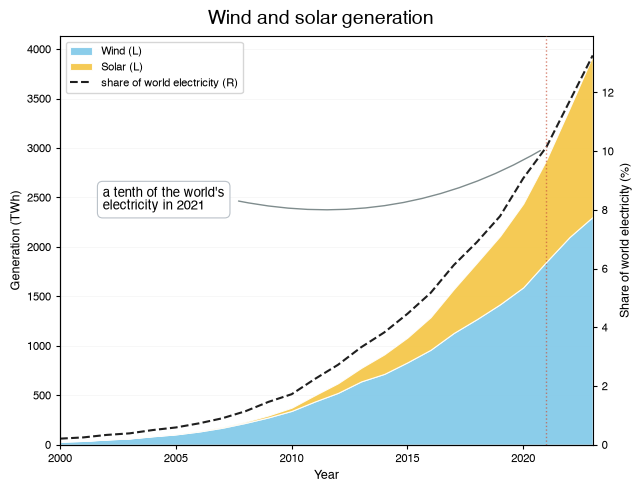

In [32]:
amount = StackedAreaChart(
    data=wind_solar,
    style=WIND_SOLAR_STYLE,
    subtitle=["Wind", "Solar"],
)
share = LineChart(
    data=wind_solar_share,
    subtitle="share of world electricity",
    style={"plot_line_color": "#1f1f1f", "plot_line_style": LINE_STYLE.DASHED},
    # the year the share passed a tenth
    vlines={"x": TENTH["x"], "style": {"plot_vline_color": "#c8553d", "plot_vline_style": LINE_STYLE.DOTTED}},
    # the note sits on the share axis with the line chart
    texts={
        "text": f"a tenth of the world's\nelectricity in {TENTH['x']}",
        "x": 0.08,
        "y": 0.6,
        "coords": "axes",
        "target": (TENTH["x"], TENTH["y"]),
    },
)

Panel(
    [
        {"figure": amount, "y_axis": "left"},
        {"figure": share, "y_axis": "right"},
    ],
    title="Wind and solar generation",
    xlabel="Year",
    ylabel_left="Generation (TWh)",
    ylabel_right="Share of world electricity (%)",
    figsize=FIG_SIZE.FULL_MEDIUM,
    show_grid=SHOW_GRID.Y,
    show_legend=True,
    legend={"location": LEGEND_LOCATION.UPPER_LEFT},
    ymin=0,
    ymin_right=0,
).show()